In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# Load data
doc_level_path = '/data/home/xiong/data/Fund/CSR/Tractions/output/df_aiv.csv'
df = pd.read_csv(doc_level_path)
print(len(df))

1177


In [3]:
df.head()

,Print ISBN,filename_staff,text_staff,filename_buff,text_buff,text_sa,paragraphs_sa,paragraphs_bu,paragraphs_sr,paragraphs_av,...,buff_verified,staff_verified,"Extract text after "":""",Full Title,Subtitle,Title,Primary Country Code,Year from title,Publication Date,has_buff
0,9781513556642,/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...",/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...","<html><body><sec id=""A01lev1sec4"">\n<title>Sta...","['25. Since the global financial crisis, Namib...",['My authorities appreciated the candid and pr...,"['1. Namibia is a small, upper middle-income c...",['9. The authorities share staff’s concerns an...,...,True,True,2015 Article IV Consultation-Press Release; S...,Namibia: 2015 Article IV Consultation-Press Re...,2015 Article IV Consultation-Press Release; St...,Namibia,NAM,2015.0,10/01/2015,1.0
1,9781475531671,/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...",NaN,NaN,"<html><body><sec id=""A01lev1sec5"">\n<title>Sta...",['34. The Uruguayan economy is decelerating gr...,NaN,['1. Uruguay’s economy performed strongly over...,['12. The authorities broadly agreed with staf...,...,False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9781475586961,/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...",/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...","<html><body><sec id=""A01lev1sec4"">\n<title>Sta...",['31. The Bulgarian economy and financial syst...,['The Bulgarian authorities highly appreciate ...,['1. Bulgaria’s reputation for macro-financial...,['9. The authorities broadly agreed with staff...,...,True,True,2015 Article IV Consultation-Staff Report; Pr...,Bulgaria: 2015 Article IV Consultation-Staff R...,2015 Article IV Consultation-Staff Report; Pre...,Bulgaria,BGR,2015.0,05/13/2015,1.0
3,9781513582290,/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...",/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...","<html><body><sec id=""A01lev1sec3"">\n<title>Sta...",['30. The Norwegian economy has so far seen li...,"['On behalf of my Norwegian authorities, I wou...",['1. A sharp oil price drop materialized towar...,['12. The authorities generally agreed with th...,...,True,True,2015 Article IV Consultation - Press Release;...,Norway: 2015 Article IV Consultation - Press R...,2015 Article IV Consultation - Press Release; ...,Norway,NOR,2015.0,09/09/2015,1.0
4,9781513542218,/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...",/data/home/xiong/data/Fund/CSR/Tractions/Artic...,"<?xml version=""1.0"" encoding=""UTF-8""?>\n<!DOCT...","<html><body><sec id=""A01lev1sec4"">\n<title>Sta...",['35. The Angolan economy has been severely af...,['Angola has witnessed substantial improvement...,['1. Angola is a post-conflict country—decades...,['17. The authorities broadly agreed with staf...,...,True,True,2015 Article IV Consultation-Press Release; S...,Angola: 2015 Article IV Consultation-Press Rel...,2015 Article IV Consultation-Press Release; St...,Angola,AGO,2015.0,11/03/2015,1.0


In [13]:
# Filter for 2015-2023 and valid years
df = df[df['Year from title'].notna()]
df['year'] = df['Year from title'].astype(int)
df = df[(df['year'] >= 2015) & (df['year'] <= 2023)]

In [ ]:
# Define income groups based on IMF/World Bank classification
# AE = Advanced Economies, EM = Emerging Markets, UC = Upper-middle + Low income countries
ae_countries = ['USA', 'GBR', 'DEU', 'FRA', 'JPN', 'CAN', 'ITA', 'ESP', 'AUS', 'NLD', 
                'BEL', 'SWE', 'CHE', 'NOR', 'DNK', 'AUT', 'FIN', 'IRL', 'NZL', 'SGP',
                'HKG', 'ISR', 'KOR', 'PRT', 'GRC', 'CZE', 'SVK', 'SVN', 'EST', 'LVA',
                'LTU', 'CYP', 'MLT', 'ISL', 'LUX']

em_countries = ['CHN', 'IND', 'BRA', 'RUS', 'MEX', 'IDN', 'TUR', 'SAU', 'ARG', 'ZAF',
                'THA', 'MYS', 'PHL', 'POL', 'EGY', 'PAK', 'VNM', 'BGD', 'NGA', 'IRQ',
                'COL', 'CHL', 'ROU', 'PER', 'UKR', 'MAR', 'KAZ', 'QAT', 'ARE', 'KWT',
                'HUN', 'DZA', 'OMN', 'HRV', 'BLR', 'BGR']

def classify_income_group(code):
    if pd.isna(code):
        return 'Unknown'
    if code in ae_countries:
        return 'AE'
    elif code in em_countries:
        return 'EM'
    else:
        return 'LC'

df['income_group'] = df['Primary Country Code'].apply(classify_income_group)
counts = df.groupby(['year', 'income_group']).size().unstack(fill_value=0)

# # Ensure all three groups exist
# for group in ['AE', 'EM', 'LC']:
#     if group not in counts.columns:
#         counts[group] = 0

# Reorder columns
counts = counts[['AE', 'EM', 'LC']]

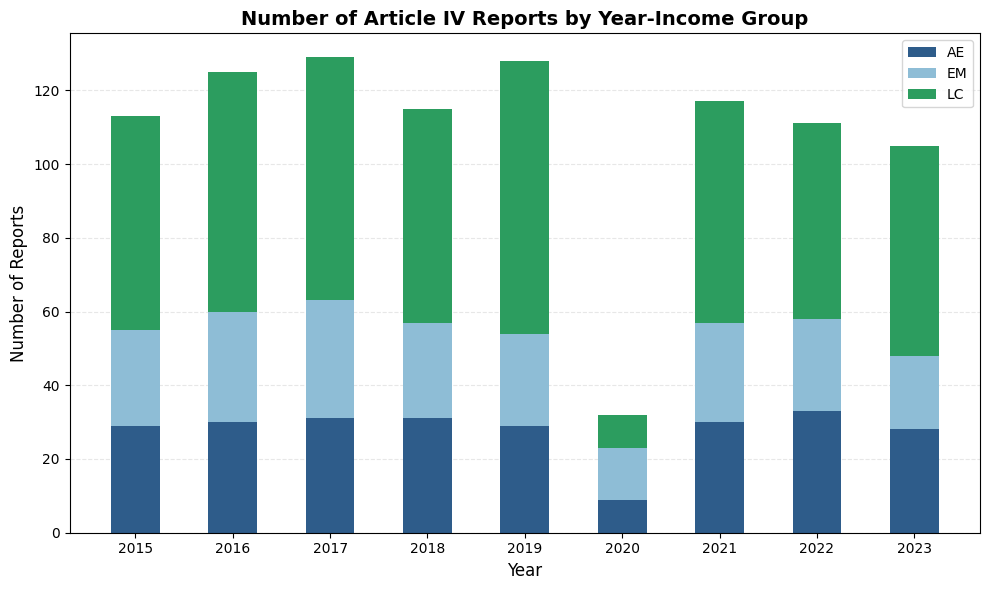


Total reports by income group:
income_group
AE    250
EM    225
LC    500
dtype: int64

Total reports: 975

Reports by year:
year
2015    113
2016    125
2017    129
2018    115
2019    128
2020     32
2021    117
2022    111
2023    105
dtype: int64


In [12]:
# Create stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
years = counts.index
width = 0.5
# Colors matching the chart
colors = {'AE': '#2E5C8A', 'EM': '#8EBDD6', 'LC': '#2C9D5F'}
# Create stacked bars
bottom = np.zeros(len(years))
for group in ['AE', 'EM', 'LC']:
    ax.bar(years, counts[group], width, label=group, 
           bottom=bottom, color=colors[group])
    bottom += counts[group].values

# Formatting
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Reports', fontsize=12)
ax.set_title('Number of Article IV Reports by Year-Income Group', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=0)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nTotal reports by income group:")
print(counts.sum())
print(f"\nTotal reports: {counts.sum().sum()}")
print(f"\nReports by year:")
print(counts.sum(axis=1))

In [16]:
# Load monetary agreement data
df_monetary = pd.read_csv('/data/home/xiong/data/Fund/CSR/Tractions/output/agreement_monetary_results.csv')

# Load country classification data to get income groups
df_aiv = pd.read_csv('/data/home/xiong/data/Fund/CSR/Tractions/output/df_aiv.csv')

# Create country code mapping from country name in df_aiv
country_code_map = df_aiv.dropna(subset=['Primary Country Code', 'Title']).set_index('Primary Country Code')['Title'].to_dict()

# Define income groups (same as before)
ae_countries = ['USA', 'GBR', 'DEU', 'FRA', 'JPN', 'CAN', 'ITA', 'ESP', 'AUS', 'NLD', 
                'BEL', 'SWE', 'CHE', 'NOR', 'DNK', 'AUT', 'FIN', 'IRL', 'NZL', 'SGP',
                'HKG', 'ISR', 'KOR', 'PRT', 'GRC', 'CZE', 'SVK', 'SVN', 'EST', 'LVA',
                'LTU', 'CYP', 'MLT', 'ISL', 'LUX']

em_countries = ['CHN', 'IND', 'BRA', 'RUS', 'MEX', 'IDN', 'TUR', 'SAU', 'ARG', 'ZAF',
                'THA', 'MYS', 'PHL', 'POL', 'EGY', 'PAK', 'VNM', 'BGD', 'NGA', 'IRQ',
                'COL', 'CHL', 'ROU', 'PER', 'UKR', 'MAR', 'KAZ', 'QAT', 'ARE', 'KWT',
                'HUN', 'DZA', 'OMN', 'HRV', 'BLR', 'BGR']

# Map country names to ISO codes (simplified mapping - may need adjustment)
country_name_to_code = {
    'United States': 'USA', 'United Kingdom': 'GBR', 'Germany': 'DEU', 'France': 'FRA',
    'Japan': 'JPN', 'Canada': 'CAN', 'Italy': 'ITA', 'Spain': 'ESP', 'Australia': 'AUS',
    'Netherlands': 'NLD', 'Belgium': 'BEL', 'Sweden': 'SWE', 'Switzerland': 'CHE',
    'Norway': 'NOR', 'Denmark': 'DNK', 'Austria': 'AUT', 'Finland': 'FIN', 'Ireland': 'IRL',
    'New Zealand': 'NZL', 'Singapore': 'SGP', 'Hong Kong SAR': 'HKG', 'Israel': 'ISR',
    'Korea': 'KOR', 'Portugal': 'PRT', 'Greece': 'GRC', 'Czech Republic': 'CZE',
    'Slovak Republic': 'SVK', 'Slovenia': 'SVN', 'Estonia': 'EST', 'Latvia': 'LVA',
    'Lithuania': 'LTU', 'Cyprus': 'CYP', 'Malta': 'MLT', 'Iceland': 'ISL', 'Luxembourg': 'LUX',
    'China': 'CHN', 'India': 'IND', 'Brazil': 'BRA', 'Russia': 'RUS', 'Mexico': 'MEX',
    'Indonesia': 'IDN', 'Turkey': 'TUR', 'Saudi Arabia': 'SAU', 'Argentina': 'ARG',
    'South Africa': 'ZAF', 'Thailand': 'THA', 'Malaysia': 'MYS', 'Philippines': 'PHL',
    'Poland': 'POL', 'Egypt': 'EGY', 'Pakistan': 'PAK', 'Vietnam': 'VNM', 'Bangladesh': 'BGD',
    'Nigeria': 'NGA', 'Iraq': 'IRQ', 'Colombia': 'COL', 'Chile': 'CHL', 'Romania': 'ROU',
    'Peru': 'PER', 'Ukraine': 'UKR', 'Morocco': 'MAR', 'Kazakhstan': 'KAZ', 'Qatar': 'QAT',
    'United Arab Emirates': 'ARE', 'Kuwait': 'KWT', 'Hungary': 'HUN', 'Algeria': 'DZA',
    'Oman': 'OMN', 'Croatia': 'HRV', 'Belarus': 'BLR', 'Bulgaria': 'BGR'
}

def get_country_code(country_name):
    """Try to map country name to ISO code"""
    if pd.isna(country_name):
        return None
    return country_name_to_code.get(country_name, country_name)

def classify_income_group_v2(country_name):
    """Classify country into income groups"""
    code = get_country_code(country_name)
    if code is None:
        return 'LIC'
    if code in ae_countries:
        return 'AE'
    elif code in em_countries:
        return 'EM'
    else:
        return 'LIC'

# Add income group classification
df_monetary['income_group'] = df_monetary['country'].apply(classify_income_group_v2)

# Filter for valid years
df_monetary = df_monetary[df_monetary['year'].notna()]
df_monetary['year'] = df_monetary['year'].astype(int)
df_monetary = df_monetary[(df_monetary['year'] >= 2015) & (df_monetary['year'] <= 2023)]

# Define "no disagreement" as agreement != 'disagreement exists'
df_monetary['no_disagreement'] = df_monetary['agreement'].apply(
    lambda x: 1 if x != 'disagreement exists' else 0
)

print(f"Total records: {len(df_monetary)}")
print(f"\nAgreement distribution:")
print(df_monetary['agreement'].value_counts())
print(f"\nIncome group distribution:")
print(df_monetary['income_group'].value_counts())


Total records: 807

Agreement distribution:
agreement
mostly agree           427
irrelevant             195
disagreement exists    185
Name: count, dtype: int64

Income group distribution:
income_group
LIC    471
EM     175
AE     161
Name: count, dtype: int64


In [17]:
# Calculate proportion without disagreement by year and income group
proportions = {}

# Calculate for ALL countries
all_by_year = df_monetary.groupby('year')['no_disagreement'].agg(['sum', 'count'])
proportions['ALL'] = (all_by_year['sum'] / all_by_year['count'] * 100).to_dict()

# Calculate for each income group
for group in ['AE', 'EM', 'LIC']:
    group_data = df_monetary[df_monetary['income_group'] == group]
    group_by_year = group_data.groupby('year')['no_disagreement'].agg(['sum', 'count'])
    proportions[group] = (group_by_year['sum'] / group_by_year['count'] * 100).to_dict()

# Convert to DataFrame for easier plotting
years = sorted(df_monetary['year'].unique())
prop_df = pd.DataFrame(index=years)
for group in ['ALL', 'AE', 'EM', 'LIC']:
    prop_df[group] = [proportions[group].get(year, np.nan) for year in years]

print("Proportion of countries without monetary sector disagreement (%):")
print(prop_df.round(1))


Proportion of countries without monetary sector disagreement (%):
       ALL    AE    EM   LIC
2015  77.3  85.7  80.0  73.2
2016  72.6  66.7  66.7  76.3
2017  78.9  86.4  75.0  77.8
2018  76.6  80.0  68.4  78.2
2019  73.3  75.0  70.0  73.9
2020  59.3  85.7  40.0  60.0
2021  82.2  87.5  63.6  88.5
2022  81.9  90.5  77.3  80.4
2023  79.2  91.3  82.4  73.2


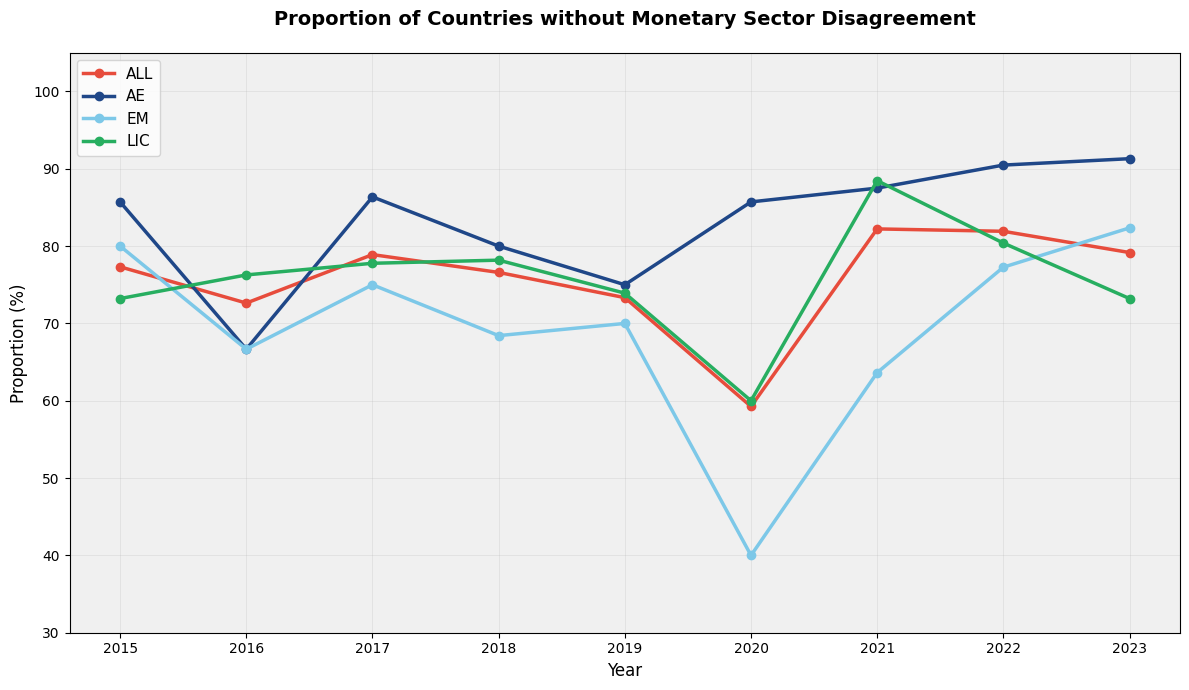

In [19]:
# Create line plot
fig, ax = plt.subplots(figsize=(12, 7))

# Define colors matching the image - AE and EM now more distinct
colors = {
    'ALL': '#E74C3C',   # Red
    'AE': '#1F4788',    # Dark Blue
    'EM': '#7DC8E8',    # Cyan/Sky Blue
    'LIC': '#27AE60'    # Green
}

# Plot each line
for group in ['ALL', 'AE', 'EM', 'LIC']:
    ax.plot(prop_df.index, prop_df[group], 
            marker='o', linewidth=2.5, markersize=6,
            label=group, color=colors[group])

# Formatting
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Proportion (%)', fontsize=12)
ax.set_title('Proportion of Countries without Monetary Sector Disagreement', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=11, frameon=True)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=0)
ax.set_ylim(30, 105)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)
ax.set_facecolor('#F0F0F0')

plt.tight_layout()
plt.show()


In [23]:
# Parse disagreement areas and categorize them
# Define categories based on keywords
categories = {
    'future policy direction': ['future policy direction', 'forward guidance', 'policy path'],
    'monetary policy operations': ['monetary policy operations', 'policy operations'],
    'monetary policy framework': ['monetary policy framework', 'policy framework'],
    'current policy stance': ['current policy stance', 'policy stance'],
    'central bank communication': ['monetary policy communication', 'central bank communication', 'communication'],
    'institutions': ['institutions', 'independence', 'governance'],
    'economic assessment': ['economic assessment'],
    'exchange rate policy': ['exchange rate policy', 'exchange rate regime', 'exchange rate flexibility'],
    'reserve requirements': ['reserve requirements'],
    'inflation target': ['inflation target']
}

def extract_categories(text):
    """Extract all disagreement categories from text"""
    if pd.isna(text):
        return []
    
    text_lower = text.lower()
    found_categories = []
    
    for category, keywords in categories.items():
        for keyword in keywords:
            if keyword in text_lower:
                found_categories.append(category)
                break  # Found this category, move to next
    
    return found_categories

# Apply categorization
df_monetary['categories'] = df_monetary['disagreement_areas'].apply(extract_categories)

# Create a row for each category (explode)
df_disagree_long = df_monetary[df_monetary['categories'].apply(len) > 0].copy()
df_disagree_long = df_disagree_long.explode('categories')

print(f"Total disagreement records: {len(df_disagree_long)}")
print(f"\nCategory distribution:")
print(df_disagree_long['categories'].value_counts())


Total disagreement records: 363

Category distribution:
categories
future policy direction       148
monetary policy framework      67
monetary policy operations     63
current policy stance          40
exchange rate policy           12
central bank communication     12
economic assessment             8
institutions                    7
inflation target                4
reserve requirements            2
Name: count, dtype: int64


In [24]:
# Calculate percentage of reports with disagreement by area and year
# First, get total reports per year (from original df_monetary)
total_reports_by_year = df_monetary.groupby('year').size()

# Count disagreements by category and year
disagree_counts = df_disagree_long.groupby(['year', 'categories']).size().unstack(fill_value=0)

# Calculate percentages
disagree_pct = (disagree_counts.div(total_reports_by_year, axis=0) * 100).round(2)

print("Percentage of reports with disagreement by area:")
print(disagree_pct)

# Fill missing categories with 0
all_categories = list(categories.keys())
for cat in all_categories:
    if cat not in disagree_pct.columns:
        disagree_pct[cat] = 0.0

disagree_pct = disagree_pct[all_categories]


Percentage of reports with disagreement by area:
categories  central bank communication  current policy stance  \
year                                                            
2015                              1.03                   6.19   
2016                              2.11                   2.11   
2017                              1.83                   8.26   
2018                              2.13                   8.51   
2019                              0.95                   6.67   
2020                              0.00                   7.41   
2021                              2.22                   0.00   
2022                              2.13                   2.13   
2023                              0.00                   4.17   

categories  economic assessment  exchange rate policy  \
year                                                    
2015                       1.03                  2.06   
2016                       0.00                  2.11   
2017   

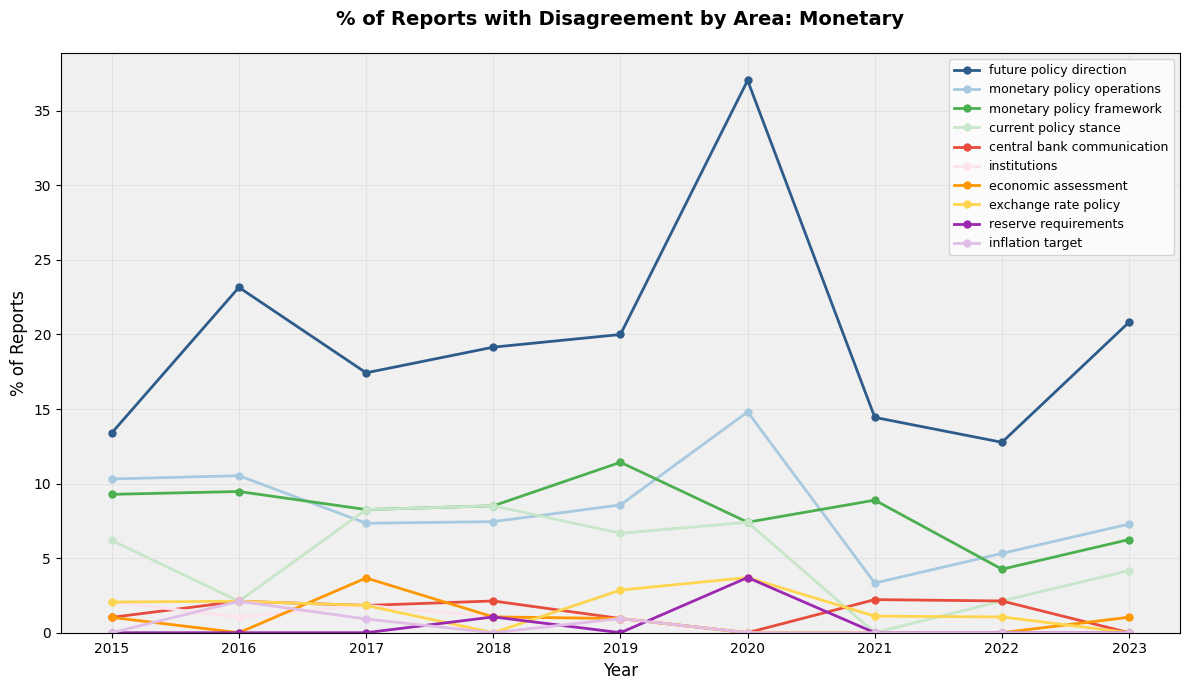

In [26]:
# Create multi-line plot for disagreement areas
fig, ax = plt.subplots(figsize=(12, 7))

# Define colors for each category (matching the chart style)
area_colors = {
    'future policy direction': '#2E5C8A',        # Dark blue
    'monetary policy operations': '#A8CAE1',     # Light blue
    'monetary policy framework': '#4CAF50',      # Green
    'current policy stance': '#C8E6C9',          # Light green
    'central bank communication': '#E74C3C',     # Red
    'institutions': '#FCE4EC',                   # Light pink
    'economic assessment': '#FF9800',            # Orange
    'exchange rate policy': '#FFD54F',           # Light orange/yellow
    'reserve requirements': '#9C27B0',           # Purple
    'inflation target': '#E1BEE7'                # Light purple
}

# Plot each category line
years_plot = disagree_pct.index
for category in all_categories:
    ax.plot(years_plot, disagree_pct[category], 
            marker='o', linewidth=2, markersize=5,
            label=category, color=area_colors.get(category, '#333333'))

# Formatting
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('% of Reports', fontsize=12)
ax.set_title('% of Reports with Disagreement by Area: Monetary', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=9, frameon=True, ncol=1)
ax.set_xticks(years_plot)
ax.set_xticklabels(years_plot, rotation=0)
# Set y-axis to start from 0 and auto-adjust the maximum
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)
ax.set_facecolor('#F0F0F0')

plt.tight_layout()
plt.show()
